## Multi Agent System with Langgraph

In [28]:
import os
from langgraph.graph import StateGraph, END
from langchain_openai import ChatOpenAI
from langchain.agents import create_agent
from langchain.tools import tool
from typing import TypedDict

### LLM

In [4]:
llm = ChatOpenAI(api_key=os.getenv('OPENAI_SECRET_KEY'),
                 model='gpt-4o-mini',
                 temperature=0)

llm

ChatOpenAI(profile={'max_input_tokens': 128000, 'max_output_tokens': 16384, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'structured_output': True, 'image_url_inputs': True, 'pdf_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'tool_choice': True}, client=<openai.resources.chat.completions.completions.Completions object at 0x00000297B4524210>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x00000297B4A47810>, root_client=<openai.OpenAI object at 0x00000297B451B190>, root_async_client=<openai.AsyncOpenAI object at 0x00000297B4A47310>, model_name='gpt-4o-mini', temperature=0.0, model_kwargs={}, openai_api_key=SecretStr('**********'), stream_usage=True)

### State

In [6]:
class AgentState(TypedDict):
    query: str
    decision: str
    math_result: str
    explanation_result: str
    final_result: str
    
AgentState

__main__.AgentState

### Tools

In [8]:
@tool
def calculator(expression:str) -> str:
    ' ''Evaluates mathematocal expressions' ''

    print('\n[CALCULATOR TOOL]')

    try:
        return str(eval(expression))
    except :
        return 'Invalid Expression'
    
calculator

StructuredTool(name='calculator', description='Evaluates mathematocal expressions', args_schema=<class 'langchain_core.utils.pydantic.calculator'>, func=<function calculator at 0x00000297B4A4F2E0>)

### Agents

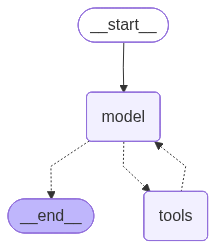

In [12]:
math_agent=create_agent(
    model=llm,
    tools=[calculator],

    system_prompt='''You are a math expert.
    You always use the calculator tool to evaluate mathematical expressions.'''
)

math_agent

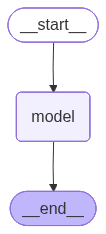

In [13]:
explain_agent=create_agent(
    model=llm,
    tools=[],
    system_prompt='''You are a helpful assistant.
    Explain the query in simple and precise language.'''
)

explain_agent

### Supervisor

In [14]:
def supervisor_node(state):
    print('\n[SUPERVISOR NODE]')
    
    prompt = f'''Decide which agent(s) to use based upon the given query. Return only the agent name.
    
Agents:
    - math
    - explanation
    - both

QUERY:
{state['query']}'''

    decision = llm.invoke(prompt).content.strip()
    print('\nDecision: ', decision)
    
    return {'decision': decision}

### Agent Nodes

In [23]:
def math_node(state):
    """Solve the given math problem"""
    
    print('\n[MATH NODE]')

    result = math_agent.invoke(
        {
            "messages": [{'role' : 'user' , 'content' : state['query']}]
        }
    )
    
    answer = result['messages'][-1].content
    return {'math_result': answer}

In [24]:
def explain_node(state):
    """Explain the AI Concepts simply and precisely"""
    
    print('\n[EXPLAIN NODE]')

    result = explain_agent.invoke(
        {
            "messages": [{'role' : 'user' , 'content' : state['query']}]
        }
    )

    answer = result['messages'][-1].content
    return {'explanation_result': answer}

In [46]:
def combine_node(state):
    print('\n{COMBINE NODE}')
    
    try:
        math_result = state['math_result']
    except:
        math_result = None

    prompt = f'''Combine the results. Provide a clean final answer.
QUERY:
{state['query']}

MATH Reuslt:
{math_result}

EXPLANATION Result:
{state['explanation_result']}'''
    
    result = llm.invoke(prompt).content.strip()
    return {'final_result': result}

In [26]:
def routing_decision_helper(state):
    return state['decision']

### Flow

In [47]:
graph = StateGraph(AgentState)

graph.add_node('supervisor_n', supervisor_node)
graph.add_node('math_n', math_node)
graph.add_node('explain_n', explain_node)
graph.add_node('combine_n', combine_node)

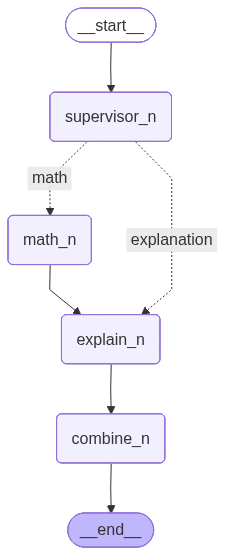

In [48]:
graph.add_conditional_edges('supervisor_n',
                            routing_decision_helper,
                            {
                                'math': 'math_n',
                                'explanation': 'explain_n',
                                #'both': 'both'
                            })

graph.add_edge('math_n', 'explain_n')
graph.add_edge('explain_n', 'combine_n')
graph.add_edge('combine_n', END)

graph.set_entry_point('supervisor_n')

app = graph.compile()
app

### Agent Call

In [49]:
def agent_call():
    while True:
        query = input('Ask (type exit to quit): ')
        
        if query.lower() in ['exit', 'quit', 'stop', 'end']:
            print('exiting......')
            break
        
        result = app.invoke(
            {'query': query}
        )
            
        print(f"\nFinal Answer: {result}")

In [50]:
agent_call()


[SUPERVISOR NODE]

Decision:  math

[MATH NODE]

[CALCULATOR TOOL]

[EXPLAIN NODE]

{COMBINE NODE}

Final Answer: {'query': 'what is 123/2', 'decision': 'math', 'math_result': 'The result of \\( 123 \\div 2 \\) is \\( 61.5 \\).', 'explanation_result': '123 divided by 2 equals 61.5.', 'final_result': 'The result of \\( 123 \\div 2 \\) is \\( 61.5 \\).'}
exiting......


In [51]:
agent_call()


[SUPERVISOR NODE]

Decision:  explanation

[EXPLAIN NODE]

{COMBINE NODE}

Final Answer: {'query': 'explain ai in 20 words', 'decision': 'explanation', 'explanation_result': 'AI, or artificial intelligence, is technology that enables machines to perform tasks that typically require human intelligence, like learning and problem-solving.', 'final_result': 'AI, or artificial intelligence, is technology that enables machines to perform tasks requiring human intelligence, such as learning and problem-solving.'}
exiting......


In [52]:
agent_call()


[SUPERVISOR NODE]

Decision:  both


KeyError: 'both'

## Query Decomposition

In [53]:
# - When we ask multiple things that require different tools in the same query then our system may not handle
# - We breakdown the queries so that we can route them to different tools accordingly.

In [57]:
def decompose_query(query):
    print(f'QUERY: ', query)
    prompt = f'''Break the given query into smaller tasks. Return them only as numbered list.
QUERY:
{query}'''

    result = llm.invoke(prompt).content.strip()
    print('[DECOMPOSED TASKS]')
    print(result)
    return result

### Task Parser

In [76]:
def parse_tasks(decomposition):
    print('\n[PARSE TASKS]')
    lines = decomposition.split('\n')
    tasks=[]

    for line in lines:
        if line.strip():
            task=line.split('.', 1)[-1].strip()
            tasks.append(task)

    print(tasks)
    return tasks

### Task Executor

In [73]:
def execute_task(task):
    print(f'\n[EXECUTING TASK]: {task}')
    
    response = llm.invoke(task).content
    # print(response)
    return response

### Full Pipeline

In [77]:
def decompose_and_run(query):
    decomposition = decompose_query(query)
    tasks = parse_tasks(decomposition)
    
    results = []
    for task in tasks:
        results.append(execute_task(task))
    
    print('\n[FINAL COMBINED ANSWER]')
    for i, res in enumerate(results):
        print(f'{i}. {res}\n')
    
    return results

In [78]:
decompose_and_run('what is 25*7? And, explain AI in brief.')

QUERY:  what is 25*7? And, explain AI in brief.
[DECOMPOSED TASKS]
1. Calculate the product of 25 and 7.
2. Provide a brief explanation of artificial intelligence (AI).

[PARSE TASKS]
['Calculate the product of 25 and 7.', 'Provide a brief explanation of artificial intelligence (AI).']

[EXECUTING TASK]: Calculate the product of 25 and 7.

[EXECUTING TASK]: Provide a brief explanation of artificial intelligence (AI).

[FINAL COMBINED ANSWER]
0. The product of 25 and 7 is \( 25 \times 7 = 175 \).

1. Artificial intelligence (AI) refers to the simulation of human intelligence processes by machines, particularly computer systems. These processes include learning (the acquisition of information and rules for using it), reasoning (the ability to solve problems through logical deduction), and self-correction. AI can be categorized into two main types: narrow AI, which is designed for specific tasks (like voice recognition or recommendation systems), and general AI, which aims to perform any 

['The product of 25 and 7 is \\( 25 \\times 7 = 175 \\).',
 'Artificial intelligence (AI) refers to the simulation of human intelligence processes by machines, particularly computer systems. These processes include learning (the acquisition of information and rules for using it), reasoning (the ability to solve problems through logical deduction), and self-correction. AI can be categorized into two main types: narrow AI, which is designed for specific tasks (like voice recognition or recommendation systems), and general AI, which aims to perform any intellectual task that a human can do. AI technologies leverage algorithms, data, and computational power to enable machines to perform tasks that typically require human intelligence, enhancing efficiency and decision-making across various fields.']

## Gaurdrails

In [79]:
# Input Guardrails
# - We restrict the user to give some illegal/unwanted query

# Output Guardrails
# - We validate the system response, it should not give some empty or grabage result

In [88]:
def input_guardrails(query):
    banned_keywords=['hack', 'attack', 'illegal']

    if any(word in query.lower() for word in banned_keywords):
        return False
    return True

In [87]:
def output_guardrails(response):
    if response.strip() and len(response)>0:
        return True
    return False

In [91]:
input_guardrails('how to attack?')

False

### Tool

In [92]:
def calculator(expression:str) -> str:
    ' ''Evaluates mathematocal expressions' ''

    print('\n[CALCULATOR TOOL]')

    try:
        return str(eval(expression))
    except :
        return 'Invalid Expression'
    
calculator

<function __main__.calculator(expression: str) -> str>

### Gaurded System

In [101]:
def guarded_system(query):
    print('\n[INPUT GUARDIAL CHECK]')

    if not input_guardrails(query=query):
        return 'Query blocked by input guardrail'

    print('Input Passed')

    print('\n[LLM PROCESSING]')

    response= llm.invoke(query).content

    print('OUTPUT GUARDRAIL CHECK')

    if not output_guardrails(response=response):
        return 'Invalid output detected'
    
    print('OUTPUT:')
    return response

In [102]:
guarded_system('how to attack a person?')


[INPUT GUARDIAL CHECK]


'Query blocked by input guardrail'

In [97]:
guarded_system('')


[INPUT GUARDIAL CHECK]
Input Passed

[LLM PROCESSING]
OUTPUT GUARDRAIL CHECK
OUTPUT:


'Hello! How can I assist you today?'

In [98]:
guarded_system('explain ai in 10 words')


[INPUT GUARDIAL CHECK]
Input Passed

[LLM PROCESSING]
OUTPUT GUARDRAIL CHECK
OUTPUT:


'AI simulates human intelligence to perform tasks and solve problems.'

In [105]:
guarded_system('given an empty response to check my system. return empty, no text')


[INPUT GUARDIAL CHECK]
Input Passed

[LLM PROCESSING]
OUTPUT GUARDRAIL CHECK


'Invalid output detected'